In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2



In [107]:
from pathlib import Path
import random

data_path = Path("../../data/raw/diabetic_retinopathy/")
#random_state = random.seed(42)
samples = list()
counter = 0
for folder in data_path.iterdir():
    if folder.is_dir():
        files = [f for f in folder.iterdir() if f.is_file()]
        if files is not None:
            random_file = random.choice(files)
            sample = {
                'file_path' : random_file,
                'file_name' : random_file.name
            }
            samples.append(sample)
        print(f"{folder.name} : {len(files)} files detected.")
        counter += len(files)

print(f"\nOverally {counter} files.")

Mild : 370 files detected.
Moderate : 999 files detected.
No_DR : 1805 files detected.
Proliferate_DR : 295 files detected.
Severe : 193 files detected.

Overally 3662 files.


In [108]:
labels_path = Path("../../data/raw/diabetic_retinopathy/train.csv")


labels = { 
        0 : "No_DR",
        1 : "Mild",
        2 : "Moderate",
        3 : "Severe",
        4 : "Proliferate_DR",
}
df = pd.read_csv(labels_path)
df

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0
...,...,...
3657,ffa47f6a7bf4,2
3658,ffc04fed30e6,0
3659,ffcf7b45f213,2
3660,ffd97f8cd5aa,0


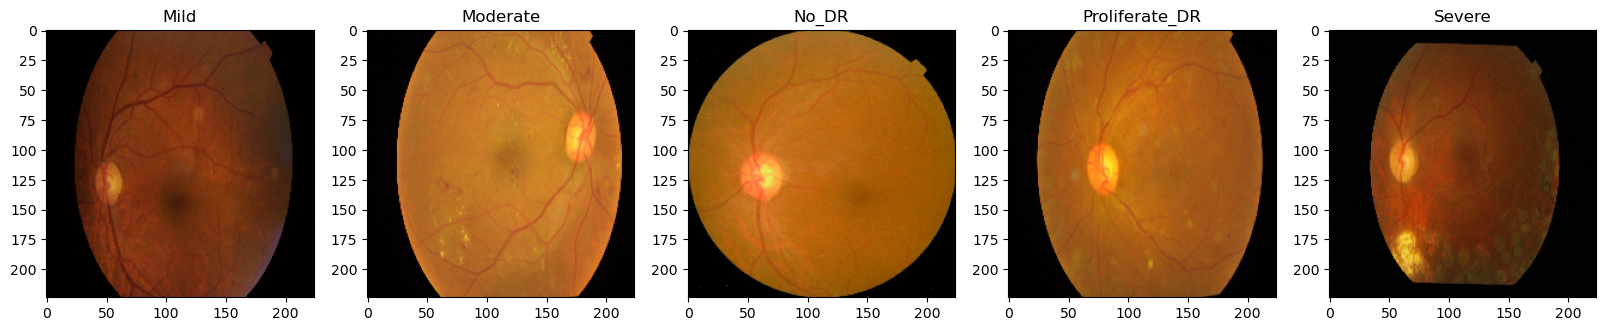

In [111]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, image in enumerate(samples):
    image_name = image["file_path"].stem
    image_label = df.loc[df["id_code"]==image_name, "diagnosis"].iloc[0]
    
    img = cv2.imread(str(image["file_path"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img);
    axes[i].set_title(labels[image_label]);
    #axes[i].axis("off")


In [110]:
samples

[{'file_path': WindowsPath('../../data/raw/diabetic_retinopathy/Mild/4e6071b73120.png'),
  'file_name': '4e6071b73120.png'},
 {'file_path': WindowsPath('../../data/raw/diabetic_retinopathy/Moderate/224bb938e2dd.png'),
  'file_name': '224bb938e2dd.png'},
 {'file_path': WindowsPath('../../data/raw/diabetic_retinopathy/No_DR/d838d5b9f571.png'),
  'file_name': 'd838d5b9f571.png'},
 {'file_path': WindowsPath('../../data/raw/diabetic_retinopathy/Proliferate_DR/2df07eb5779f.png'),
  'file_name': '2df07eb5779f.png'},
 {'file_path': WindowsPath('../../data/raw/diabetic_retinopathy/Severe/e1fb532f55df.png'),
  'file_name': 'e1fb532f55df.png'}]